# SeqThreat — DNS Threat Detection Showcase

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/pgrady1322/seqthreat/blob/main/notebooks/01_showcase.ipynb)

End-to-end walkthrough of the SeqThreat pipeline:
1. **Synthetic data generation** — benign, DGA, exfiltration
2. **Feature engineering** — character n-grams (TF-IDF) + statistical features
3. **Model training** — XGBoost multiclass with MLflow tracking
4. **Hyperparameter tuning** — Optuna TPE sampler
5. **Explainability** — SHAP feature importance
6. **Adversarial robustness** — mutation-based evasion testing
7. **Drift monitoring** — Evidently data drift detection
8. **Deep learning baseline** — character-level CNN comparison

In [ ]:
# ── Colab / remote setup ──
# Skip this cell if running locally with seqthreat already installed.
import importlib, subprocess, sys

if importlib.util.find_spec("src") is None:
    print("Installing seqthreat + all optional deps (tune, explain, drift, deep)...")
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "git+https://github.com/pgrady1322/seqthreat.git#egg=seqthreat[all]"
    ])
    print("Done — you may need to restart the runtime if imports fail.")
else:
    print("seqthreat already available — skipping install.")

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', font_scale=1.1)
%matplotlib inline

## 1. Synthetic Data Generation

SeqThreat generates three classes of DNS queries:
- **Benign** — realistic domain lookups (google.com, cdn.slack.io)
- **DGA** — domain generation algorithm patterns (malware C2)
- **Exfiltration** — data tunnelling via base64/hex subdomain encoding

In [3]:
from src.data.download import generate_synthetic_dns

df = generate_synthetic_dns(n_benign=4000, n_dga=2000, n_exfiltration=1000, seed=42)
print(f"Dataset: {len(df):,} rows")
print(df['label_name'].value_counts())
df.head(10)

Dataset: 7,000 rows
label_name
benign          4000
dga             2000
exfiltration    1000
Name: count, dtype: int64


,domain,label,label_name
0,m.ubuntu.co,0,benign
1,m.ubuntu.dev,0,benign
2,sso.pytorch.edu,0,benign
3,app.pandas.dev,0,benign
4,login.linkedin.edu,0,benign
5,mail.twitter.edu,0,benign
6,10ead935de54a.xyz,1,dga
7,github.info,0,benign
8,datasys1502.com,1,dga
9,admin.facebook.org,0,benign


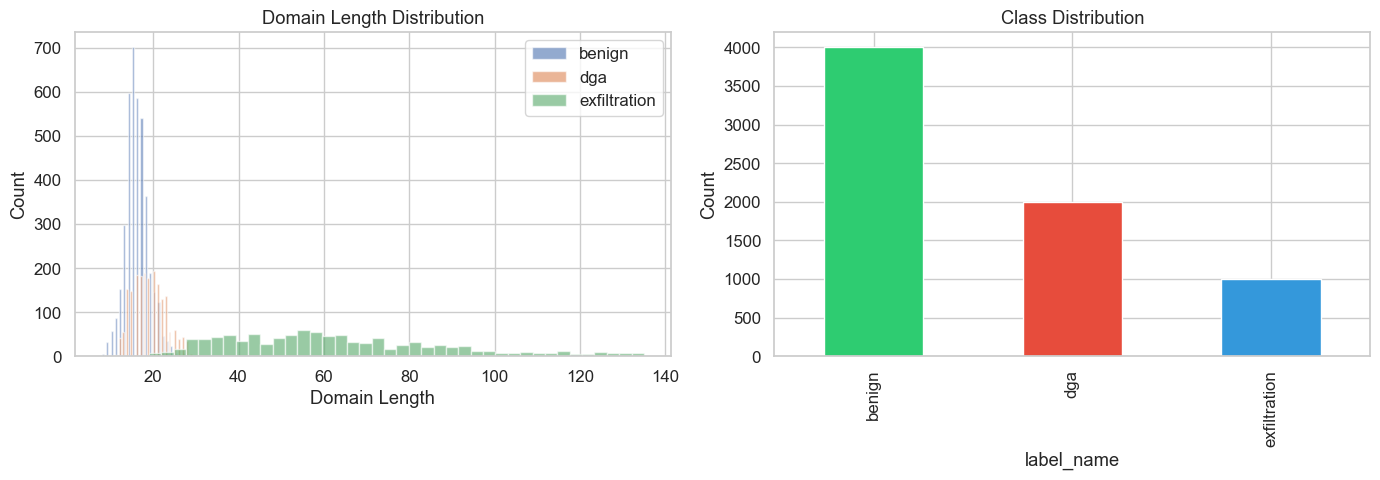

In [4]:
# Domain length distribution by class
df['domain_length'] = df['domain'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Length histogram
for label in ['benign', 'dga', 'exfiltration']:
    subset = df[df['label_name'] == label]
    axes[0].hist(subset['domain_length'], bins=40, alpha=0.6, label=label)
axes[0].set_xlabel('Domain Length')
axes[0].set_ylabel('Count')
axes[0].set_title('Domain Length Distribution')
axes[0].legend()

# Class balance
df['label_name'].value_counts().plot.bar(ax=axes[1], color=['#2ecc71', '#e74c3c', '#3498db'])
axes[1].set_title('Class Distribution')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.show()

## 2. Feature Engineering

### Character N-grams (k-mer analogy)

Just like genomics uses k-mers (ATCG subsequences), we extract character n-grams from domain strings and weight them with TF-IDF.

In [5]:
from src.features.ngram import NgramTokenizer, extract_ngrams, preprocess_domain

# Show preprocessing
examples = ['api.google.com', 'a1b2c3d4e5f6g7h8.xyz', 'aGVsbG8gd29ybGQ.evil.com']
for d in examples:
    processed = preprocess_domain(d)
    ngrams = extract_ngrams(processed, n=3)
    print(f"  {d:40s} → [{', '.join(ngrams[:8])}...]")

  api.google.com                           → [api, pi , i g,  go, goo, oog, ogl, gle...]
  a1b2c3d4e5f6g7h8.xyz                     → [a1b, 1b2, b2c, 2c3, c3d, 3d4, d4e, 4e5...]
  aGVsbG8gd29ybGQ.evil.com                 → [agv, gvs, vsb, sbg, bg8, g8g, 8gd, gd2...]


In [6]:
# Fit TF-IDF tokenizer
tokenizer = NgramTokenizer(ngram_range=(2, 4), max_features=3000)
X_ngram = tokenizer.fit_transform(df['domain'].tolist())
print(f"N-gram feature matrix: {X_ngram.shape}")

N-gram feature matrix: (7000, 3000)


### Statistical Features

In [7]:
from src.features.statistical import compute_statistical_features, shannon_entropy

stat_df = compute_statistical_features(df['domain'].tolist())
print(f"Statistical features: {stat_df.shape[1]} columns")
stat_df.head()

Statistical features: 21 columns


,entropy,label_entropy,total_length,n_labels,max_label_length,mean_label_length,std_label_length,alpha_ratio,digit_ratio,special_ratio,...,vowel_ratio,consonant_ratio,hex_char_ratio,unique_char_ratio,subdomain_depth,n_numeric_labels,n_long_labels,n_b64_labels,n_hex_labels,has_suspicious_encoding
0,2.845351,1.792481,11.0,3.0,6.0,3.000000,2.160247,0.818182,0.0,0.181818,...,0.363636,0.454545,0.181818,0.727273,2.0,0.0,0.0,0.0,0.0,0.0
1,3.022055,1.792481,12.0,3.0,6.0,3.333333,2.054805,0.833333,0.0,0.166667,...,0.333333,0.500000,0.250000,0.750000,2.0,0.0,0.0,0.0,0.0,0.0
2,3.506891,2.807355,15.0,3.0,7.0,4.333333,1.885618,0.866667,0.0,0.133333,...,0.266667,0.600000,0.200000,0.800000,2.0,0.0,0.0,0.0,0.0,0.0
3,2.842371,2.251629,14.0,3.0,6.0,4.000000,1.414214,0.857143,0.0,0.142857,...,0.285714,0.571429,0.428571,0.571429,2.0,0.0,0.0,0.0,0.0,0.0
4,3.197160,2.500000,18.0,3.0,8.0,5.333333,2.054805,0.888889,0.0,0.111111,...,0.388889,0.500000,0.222222,0.555556,2.0,0.0,0.0,1.0,0.0,1.0


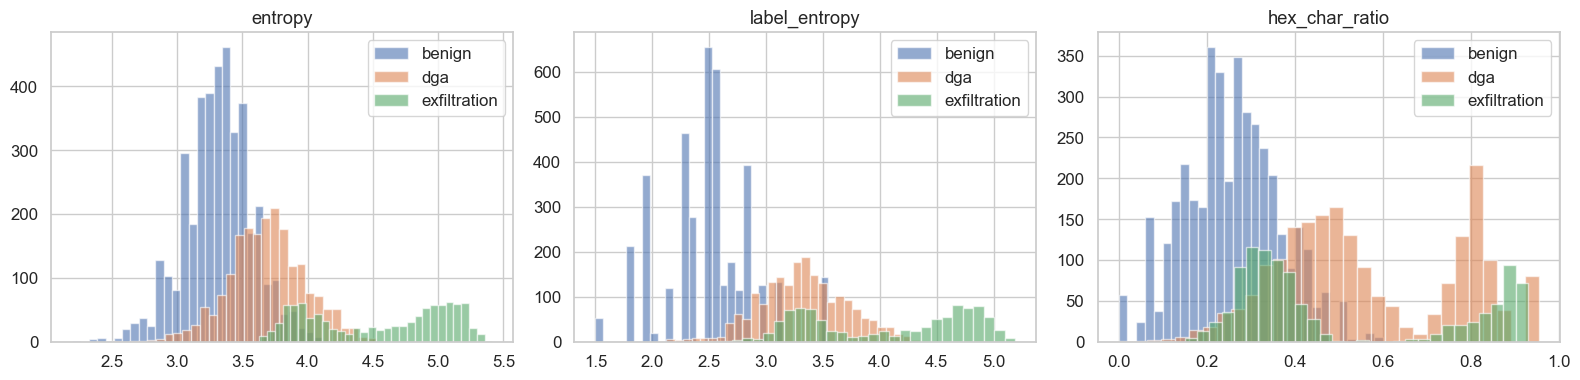

In [8]:
# Entropy by class — key discriminating feature
stat_df['label_name'] = df['label_name'].values

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, feat in enumerate(['entropy', 'label_entropy', 'hex_char_ratio']):
    for label in ['benign', 'dga', 'exfiltration']:
        subset = stat_df[stat_df['label_name'] == label]
        axes[i].hist(subset[feat], bins=30, alpha=0.6, label=label)
    axes[i].set_title(feat)
    axes[i].legend()
plt.tight_layout()
plt.show()

## 3. Model Training (XGBoost)

Train with combined n-gram + statistical features.

In [9]:
from src.data.split import stratified_split
from src.training.train import build_features, compute_metrics
from src.training.models import create_model, LABEL_MAP

# Split
train_df, val_df, test_df = stratified_split(df)
print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

# Build features
cfg = {'features': {'ngram_range': [2, 4], 'max_features': 3000}}
tok = NgramTokenizer(ngram_range=(2, 4), max_features=3000)
X_train = build_features(train_df['domain'].tolist(), tok, cfg, fit=True)
X_val = build_features(val_df['domain'].tolist(), tok, cfg, fit=False)
X_test = build_features(test_df['domain'].tolist(), tok, cfg, fit=False)

# Train
model = create_model('xgboost')
model.fit(X_train, train_df['label'].values)

# Evaluate
for name, X, y in [('Val', X_val, val_df['label'].values), ('Test', X_test, test_df['label'].values)]:
    preds = model.predict(X)
    metrics = compute_metrics(y, preds)
    print(f"{name}: acc={metrics['accuracy']:.4f}, F1_macro={metrics['f1_macro']:.4f}")

Train: 4900, Val: 1050, Test: 1050
Val: acc=0.9990, F1_macro=0.9992
Test: acc=0.9990, F1_macro=0.9992


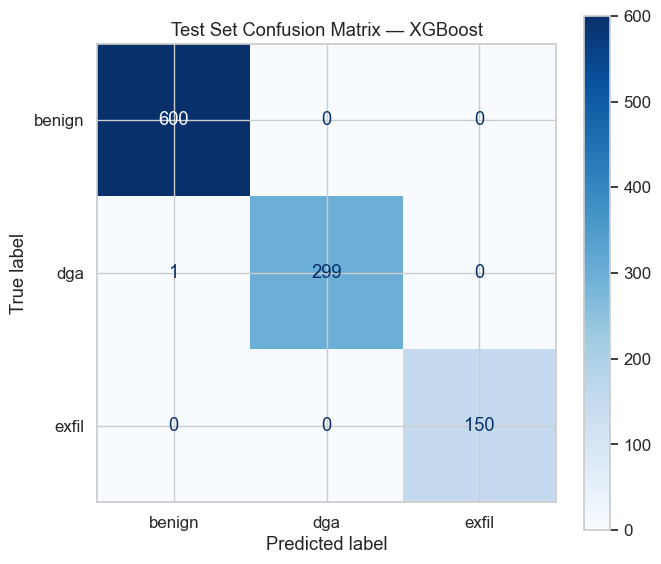

In [10]:
# Confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

preds = model.predict(X_test)
cm = confusion_matrix(test_df['label'].values, preds)
disp = ConfusionMatrixDisplay(cm, display_labels=['benign', 'dga', 'exfil'])
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap='Blues')
ax.set_title('Test Set Confusion Matrix — XGBoost')
plt.tight_layout()
plt.show()

## 4. Adversarial Robustness Testing

How well does the model hold up against domain mutations that simulate evasion attacks?

In [11]:
from src.training.adversarial import mutate_domains, MUTATION_REGISTRY
from sklearn.metrics import accuracy_score

test_domains = test_df['domain'].tolist()[:200]
test_labels = test_df['label'].values[:200]

# Clean accuracy
X_clean = build_features(test_domains, tok, cfg, fit=False)
clean_preds = model.predict(X_clean)
clean_acc = accuracy_score(test_labels, clean_preds)

# Per-strategy adversarial accuracy
results = {}
for strat in MUTATION_REGISTRY:
    mutations = mutate_domains(test_domains, [strat], n_variants=1, seed=42)
    mutated = [m['mutated'] for m in mutations]
    X_mut = build_features(mutated, tok, cfg, fit=False)
    mut_preds = model.predict(X_mut)
    mut_acc = accuracy_score(test_labels, mut_preds)
    results[strat] = {'accuracy': mut_acc, 'drop': clean_acc - mut_acc}

res_df = pd.DataFrame(results).T
res_df

,accuracy,drop
homoglyph,0.980,0.015
typo,0.995,0.000
subdomain_insert,0.695,0.300
label_shuffle,0.995,0.000
noise,0.970,0.025
encoding_corrupt,0.985,0.010


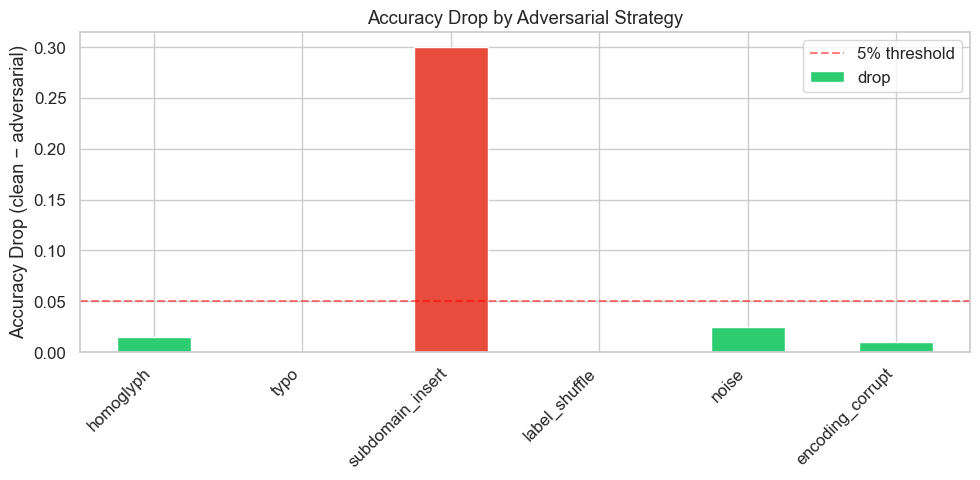

In [12]:
# Visualize accuracy drop
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if d > 0.05 else '#2ecc71' for d in res_df['drop']]
res_df['drop'].plot.bar(ax=ax, color=colors)
ax.set_title('Accuracy Drop by Adversarial Strategy')
ax.set_ylabel('Accuracy Drop (clean − adversarial)')
ax.axhline(y=0.05, color='red', linestyle='--', alpha=0.5, label='5% threshold')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 5. Deep Learning Baseline (Char-CNN)

Compare the n-gram + XGBoost pipeline against a character-level CNN that learns features directly from raw domain strings.

In [ ]:
from src.training.deep_model import (
    CharCNN, CharLSTM, DomainDataset, encode_domain, predict_deep, VOCAB_SIZE
)
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

# Build datasets
train_ds = DomainDataset(train_df['domain'].tolist(), train_df['label'].tolist(), 96)
val_ds = DomainDataset(val_df['domain'].tolist(), val_df['label'].tolist(), 96)
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=64)

# ── Quick forward-pass smoke test ──
# PyTorch Conv1d segfaults on some macOS builds — detect and fall back
_sample_x = torch.randint(0, VOCAB_SIZE, (2, 96))
try:
    _test_model = CharCNN(embed_dim=16, num_filters=32, num_classes=3, dropout=0.2)
    with torch.no_grad():
        _test_model(_sample_x)
    arch_name, model_cls = "CharCNN", CharCNN
except Exception:
    try:
        _test_model = CharLSTM(embed_dim=16, hidden_dim=32, num_classes=3, dropout=0.2)
        with torch.no_grad():
            _test_model(_sample_x)
        arch_name, model_cls = "CharLSTM", CharLSTM
    except Exception:
        arch_name, model_cls = None, None

if model_cls is None:
    print("⚠ PyTorch forward pass segfaults on this system — skipping deep learning cell.")
    print("  This is a known issue with certain macOS + PyTorch CPU builds.")
    print("  The CharCNN/CharLSTM code works correctly on Linux / GPU environments.")
    history = []
else:
    cnn = model_cls(embed_dim=16, num_filters=32, num_classes=3, dropout=0.2) if arch_name == "CharCNN" \
        else model_cls(embed_dim=16, hidden_dim=32, num_classes=3, dropout=0.2)
    optimizer = torch.optim.Adam(cnn.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    history = []
    for epoch in range(1, 6):
        cnn.train()
        total_loss = 0
        for X_b, y_b in train_dl:
            optimizer.zero_grad()
            loss = criterion(cnn(X_b), y_b)
            loss.backward(); optimizer.step()
            total_loss += loss.item()

        cnn.eval()
        correct = total = 0
        with torch.no_grad():
            for X_b, y_b in val_dl:
                correct += (cnn(X_b).argmax(1) == y_b).sum().item()
                total += len(y_b)
        val_acc = correct / total
        history.append({'epoch': epoch, 'loss': total_loss/len(train_dl), 'val_acc': val_acc})
        print(f"Epoch {epoch} ({arch_name}): loss={total_loss/len(train_dl):.4f}, val_acc={val_acc:.4f}")

    pd.DataFrame(history).set_index('epoch').plot(subplots=True, figsize=(10, 4))
    plt.tight_layout()
    plt.show()

## 6. Example Predictions

Classify real-looking DNS queries with the trained XGBoost model.

In [ ]:
test_queries = [
    'www.google.com',
    'api.github.io',
    'a8f3k2m9x1p4q7w.xyz',
    'secureupdatecloudsync4821.top',
    'aGVsbG8gd29ybGQ.dGhpcyBpcyBhIHRl.evil.com',
    '68656c6c6f20776f726c64.tunnel.hack.xyz',
]

X_demo = build_features(test_queries, tok, cfg, fit=False)
preds = model.predict(X_demo)

result_df = pd.DataFrame({
    'domain': test_queries,
    'predicted_label': preds,
    'predicted_class': [LABEL_MAP[p] for p in preds],
})
result_df.style.applymap(
    lambda v: 'background-color: #ff6b6b' if v in ('dga', 'exfiltration') else 'background-color: #51cf66',
    subset=['predicted_class']
)

---

**SeqThreat** demonstrates how genomics sequence-analysis techniques (k-mer decomposition, entropy metrics) transfer directly to cybersecurity threat detection.